In [32]:
1+1

2

Building basic chatbot graphapi

In [33]:
###building basic chatbot
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END

from langgraph.graph.message import add_messages 

class State(TypedDict):
    messages:Annotated[list,add_messages]

graph_builder = StateGraph(State)
graph_builder

In [34]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm =  ChatGroq(model="llama-3.1-8b-instant")
# llm = init_chat_model("groq:llama3-8b-8192")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x10d60cc10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10d60e8d0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [35]:

#Node functionality
def chatbot_(state:State):
    return  {"messages":[llm.invoke(state["messages"])]} 

##adding nodes
graph_builder.add_node("llmchatbot",chatbot_)
##addig edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)


graph = graph_builder.compile()

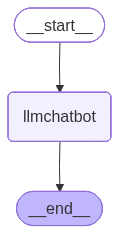

In [36]:
from IPython.display import Image,display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))

except Exception:
    pass

In [37]:
result = graph.invoke({"messages": [{"role": "user", "content": "Hi!"}]})
print(result["messages"])

[HumanMessage(content='Hi!', additional_kwargs={}, response_metadata={}, id='0dbc51cc-53df-4321-a5fd-6bfdaeaa5327'), AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 37, 'total_tokens': 60, 'completion_time': 0.028547463, 'completion_tokens_details': None, 'prompt_time': 0.002338471, 'prompt_tokens_details': None, 'queue_time': 0.033162761, 'total_time': 0.030885934}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f699a-7c75-7350-9d82-b98157ad33f2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 23, 'total_tokens': 60})]


In [38]:
for event in graph.stream({"messages":"Hello how are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm just a computer program, so I don't have feelings like humans do, but I'm functioning properly and ready to help you with any questions or tasks you have. How can I assist you today?


In [39]:
##Chatbot with tool

from langchain_tavily import TavilySearch
tool = TavilySearch(max_result=2)
tool.invoke("who won fifa worldcup semi today?")

{'query': 'who won fifa worldcup semi today?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.abc.net.au/news/sport/score-centre/fifa-world-cup/2026-07-20/semifinal-1-winner-semifinal-2-winner/2608362',
   'title': 'Semi-Final 1 Winner v Semi-Final 2 Winner - Final - FIFA World Cup Score Centre - ABC News',
   'content': "Skip to news navigation, settings and search. ## Explore the ABC. 2. FIFA World Cup Score Centre|. 3. Semi-Final 1 Winner v Semi-Final 2 Winner. ## Match summary: Semi-Final 1 Winner v Semi-Final 2 Winner. Final: Latest FIFA World Cup score and results. Catch up on this week's latest scores and FIFA World Cup stories with ABC Sport. ## FIFA World Cup Ladder. ## ABC Live sport. Live coverage of the best sport from around the country. ### Latest FIFA World Cup stories. ### Spain shocks France to put World Cup favourite on brink of exit. ### Spain 'here to suffer' and France unites against racism ahead of World Cup semi. A

In [40]:
##cuustomer functions:


def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    returns:
        int: output int
    
    """
    return a*b

tools =[tool,multiply]
llm_with_tools = llm.bind_tools(tools)
llm_with_tools



_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x10d60cc10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10d60e8d0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized fo

In [41]:
###Stategraph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

##Node defintio
def tool_calling_llm(state:State):
    return{"messages":[llm_with_tools.invoke(state["messages"])]}

#graph

builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))



##add edges

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

builder.add_edge("tools",END)

#COMPILE

graph =builder.compile()


In [42]:
repsonse = graph.invoke({"messages":"who won semi final tooday fifa world cup"})

In [43]:
repsonse['messages'][-1].content

'{"query": "fifa world cup semi final result today", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.skysports.com/football/france-vs-spain/549866", "title": "World Cup 2026: France 0-2 Spain - Mikel Oyarzabal and Pedro Porro strike as European champions reach final - Sky Sports", "score": 0.66959417, "published_date": "Wed, 15 Jul 2026 23:34:31 GMT", "content": "# France vs Spain; FIFA World Cup Semi-Final. FIFA World Cup Semi-Final. # World Cup 2026: France 0-2 Spain - Mikel Oyarzabal and Pedro Porro strike as European champions reach final. Match report as Mikel Oyarzabal\'s penalty and a strike from Pedro Porro send Spain into the World Cup final; France had joint-top scorer Kylian Mbappe and top assist-maker Michael Olise but their attack failed to fire in a poor performance; Spain will face England or Argentina on Sunday. European champions Spain are into the World Cup final after beating lacklustre France 2-0 in Dallas. As bad as Franc

In [44]:
repsonse = graph.invoke({"messages":"What is 2 * 3"})
repsonse['messages'][-1].content

'6'

In [45]:
repsonse

{'messages': [HumanMessage(content='What is 2 * 3', additional_kwargs={}, response_metadata={}, id='96749661-9ff7-4f38-8b15-d4f498fc0135'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '65221njh3', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 1752, 'total_tokens': 1771, 'completion_time': 0.026095506, 'completion_tokens_details': None, 'prompt_time': 0.071839073, 'prompt_tokens_details': {'cached_tokens': 1024}, 'queue_time': 0.031405751, 'total_time': 0.097934579}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f699a-8145-7f33-866a-0e894fee67d8-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': '65221njh3', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens':

In [51]:
###Stategraph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

##Node defintio
def tool_calling_llm(state:State):
    return{"messages":[llm_with_tools.invoke(state["messages"])]}

#graph

builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))



##add edges

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

builder.add_edge("tools","tool_calling_llm")

#COMPILE

graph =builder.compile()


repsonse = graph.invoke({"messages":"What is 2 * 3 and then give weather today"})
repsonse['messages'][-1].content

'The current weather is clear with a temperature of 28.7°C (83.7°F) and a humidity of 77%. There is a gentle wind blowing at 7.2 km/h (4.5 mph) from the southeast direction. The forecast suggests a high chance of rain in the next few days, with temperatures ranging from 25.8° to 36.8° Celsius (78.4° to 98.2° Fahrenheit) during the day and 13.6° to 19.6° Celsius (56.5° to 67.3° Fahrenheit) at night.'